In [2]:
import predealimg
import numpy as np
import os
import multiprocess as mp
import matplotlib.pyplot as plt
import scipy.io
from PIL import Image


In [3]:
dict_decode={'0':'2','1':'3','2':'4','3':'5','4':'7','5':'9','6':'A','7':'C','8':'F','9':'H','10':'K','11':'M','12':'N'
      ,'13':'P','14':'Q','15':'R','16':'T','17':'Y','18':'Z'}
dict_encode={'2':'0','3':'1','4':'2','5':'3','7':'4','9':'5','A':'6','C':'7','F':'8','H':'9','K':'10','M':'11','N':'12'
      ,'P':'13','Q':'14','R':'15','T':'16','Y':'17','Z':'18'}

In [8]:
def Creat_X_Test():
    path='DLmidterm/crawlimg/'
    #train
    x_list=[]
#     for i in range(len(os.listdir(path))):
#         arr=cvimgtest.Deal_With_TestImg(i)
#         x_list.append(arr)
    #test
    y=[]
    for i,c in enumerate(os.listdir(path)):
        img=np.array(Image.open(path+c))
        x_list.append(img)
        for num in range(4):
            y.append(int(dict_encode[c[num]]))
    x=np.array([x_list])
    return x,y

In [9]:
def OneHot(data):
    onehotarr=np.uint8(np.zeros((len(data),19)))
    for i,c in enumerate(data):
        onehotarr[i][c]=1
    return onehotarr


In [10]:
def OneHotEncode(data):
    delst=[]
    enlst=np.uint8(np.zeros((1,data.shape[0])))
    for i in range(data.shape[0]):
        d=dict_decode[str(np.argmax(data[i]))]
        enlst[0][i]=str(np.argmax(data[i]))
        delst.append(d)
    return delst,enlst


In [11]:
x,y=Creat_X_Test()
dy=OneHot(y)
_,y=OneHotEncode(dy)

In [12]:
save_fn = 'DLmidterm/owntest.mat'
scipy.io.savemat(save_fn, {'x': x,'y':y,'y_onehot':dy})


In [19]:
data=scipy.io.loadmat('DLmidterm/test.mat')
x1,y1,y1_onehot=data["x"],data["y"],data["y_onehot"]
data1=scipy.io.loadmat('DLmidterm/train.mat')   
x2,y2,y2_onehot=data1["x"],data1["y"],data1["y_onehot"]
data3=scipy.io.loadmat('DLmidterm/owntest.mat')
x3,y3,y3_onehot=data3["x"],data3["y"],data3["y_onehot"]


In [20]:
y3.shape

(1, 388)

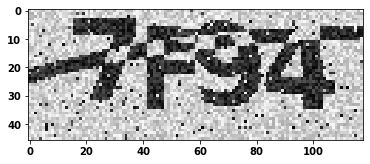

In [3]:
plt.imshow(x1[0][0])

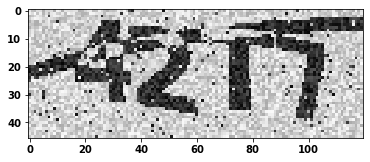

In [4]:
plt.imshow(x1[0][1])

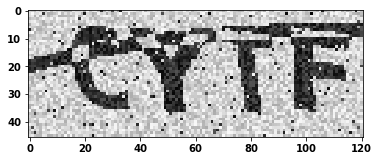

In [5]:
plt.imshow(x1[0][2])

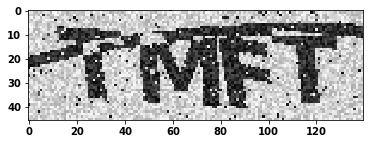

In [6]:
plt.imshow(x1[0][3])

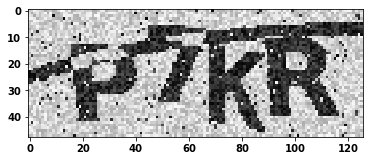

In [7]:
plt.imshow(x1[0][4])

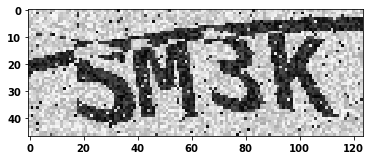

In [8]:
plt.imshow(x1[0][39])